# Visualising cointegrated pairs across a universe

Universe-wide screening and its visual diagnostics, built on the package API:

1. **Data** — packaged universes, `load_prices()`, full-coverage filter, parquet caches.
2. **Screening and the multiple-testing audit** — `find_cointegrated_pairs_dualgate()` with the
   Benjamini–Hochberg (BH) correction on the Nasdaq-100 *and* on the combined S&P 500 + Nasdaq-100
   universe. The Nasdaq-100 alone is the cautionary tale: its raw-p "cointegration network" collapses to
   nothing once false discoveries are controlled.
3. **The network** (combined universe) — heatmap, Kamada-Kawai graph with community colouring and hub
   detection, degree distribution, the network with the hubs removed, and a clustered heatmap.
4. **Trading diagnostics** — Kalman hedge on every surviving pair, spread half-life and stationarity
   summary, and a gallery of the most tradeable spreads.
5. **Partner query** — one function that lists a ticker's cointegrated partners with all the diagnostics.

Prices and screens are cached under `notebooks/cache/` (gitignored); a cold run downloads ~600 tickers
and screens ~120k pairs (about 8 minutes on 16 cores), a warm run takes about a minute.

## 0. Setup

In [1]:
from pathlib import Path
import sys, time, warnings

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.cluster.hierarchy import linkage, leaves_list

import pairs
from pairs import (load_universe, load_prices, find_cointegrated_pairs_dualgate,
                   fit_kalman_hedge, summarize_spread_stationarity_joblib)

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
START, END, ALPHA = "2020-01-01", "2025-12-31", 0.05
UNIVERSES = {"ndx": "Nasdaq-100", "spx_ndx_combined": "S&P 500 + Nasdaq-100"}
MAIN = "spx_ndx_combined"
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})
print("pairs", pairs.__version__, "| networkx", nx.__version__)

pairs 0.1.0 | networkx 3.6.1


## 1. Data

Daily closes for both universes through the package loader, cached as parquet. Tickers that do not span
the full window are dropped, as in the pipeline notebooks, because the cointegration tests require
full-span coverage.

In [2]:
def full_coverage(df: pd.DataFrame) -> pd.DataFrame:
    dt = df.index.get_level_values("datetime")
    g = df.groupby(level="ticker")
    starts = g.apply(lambda x: x.index.get_level_values("datetime").min())
    ends   = g.apply(lambda x: x.index.get_level_values("datetime").max())
    keep = starts[(starts == dt.min()) & (ends == dt.max())].index
    return df.loc[pd.IndexSlice[keep, :]]

def load_universe_prices(name: str) -> pd.DataFrame:
    f = CACHE / f"viz_prices_{name}.parquet"
    if f.exists():
        df, failed = pd.read_parquet(f), []
    else:
        tickers = load_universe(name)
        df, failed = load_prices("openbb", tickers, START, END, return_failed=True, show_progress=False)
        df.to_parquet(f)
    n_all = df.index.get_level_values("ticker").nunique()
    df = full_coverage(df)
    print(f"{UNIVERSES[name]:22s} {n_all:>4d} tickers downloaded"
          + (f" ({len(failed)} failed)" if failed else "")
          + f" → {df.index.get_level_values('ticker').nunique():>4d} with full coverage, "
          f"{df.index.get_level_values('datetime').nunique()} bars")
    return df

prices = {name: load_universe_prices(name) for name in UNIVERSES}

Nasdaq-100              100 tickers downloaded →   92 with full coverage, 1508 bars


S&P 500 + Nasdaq-100    505 tickers downloaded →  488 with full coverage, 1508 bars


## 2. Screening and the multiple-testing audit

Both gates of the package screen — Engle–Granger with BH-adjusted p-values, and Johansen — on every pair
of each universe. The audit table compares what the raw Engle–Granger test "finds" with what is expected
by chance and what survives the correction.

In [3]:
def screen(name: str, df: pd.DataFrame) -> pd.DataFrame:
    f = CACHE / f"viz_screen_{name}.parquet"
    if f.exists():
        return pd.read_parquet(f)
    t0 = time.time()
    s = find_cointegrated_pairs_dualgate(df, alpha_eg=ALPHA, eg_trend="c",
                                         alpha_joh=ALPHA, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
                                         fdr_method="bh", chunksize=32, show_progress=True)
    s.to_parquet(f)
    print(f"{UNIVERSES[name]}: {len(s):,} pairs screened in {time.time() - t0:.0f}s")
    return s

screens = {name: screen(name, df) for name, df in prices.items()}

def audit(s: pd.DataFrame) -> dict:
    return {"pairs tested":                     len(s),
            f"expected false positives at {ALPHA:.0%}": int(round(ALPHA * len(s))),
            f"raw Engle–Granger p ≤ {ALPHA}":  int((s["eg_p"] <= ALPHA).sum()),
            "BH-significant Engle–Granger":     int(s["eg_pass"].sum()),
            f"Johansen trace at {ALPHA:.0%}":   int(s["joh_pass"].sum()),
            "dual-gate pass (BH EG ∧ Johansen)": int((s["verdict"] == "pass").sum())}

audit_df = pd.DataFrame({UNIVERSES[k]: audit(v) for k, v in screens.items()})
audit_df

,Nasdaq-100,S&P 500 + Nasdaq-100
pairs tested,4186,118828
expected false positives at 5%,209,5941
raw Engle–Granger p ≤ 0.05,233,8923
BH-significant Engle–Granger,0,280
Johansen trace at 5%,387,15340
dual-gate pass (BH EG ∧ Johansen),0,279


**Reading the audit.** On the Nasdaq-100 the raw test flags about as many pairs as chance alone would, and
the BH correction keeps none of them: at this sample size and horizon the Nasdaq-100 has *no* detectable
cointegrated pairs, and any network drawn from the raw p-values is a picture of noise. The combined
universe screens nearly thirty times as many pairs and keeps a few hundred after correction — enough to
study — but the audit already warns that "significant" is a small fraction of "tested".

The picture makes the point better than the table: the same Nasdaq-100 data, raw p-values on the left,
BH-corrected on the right.

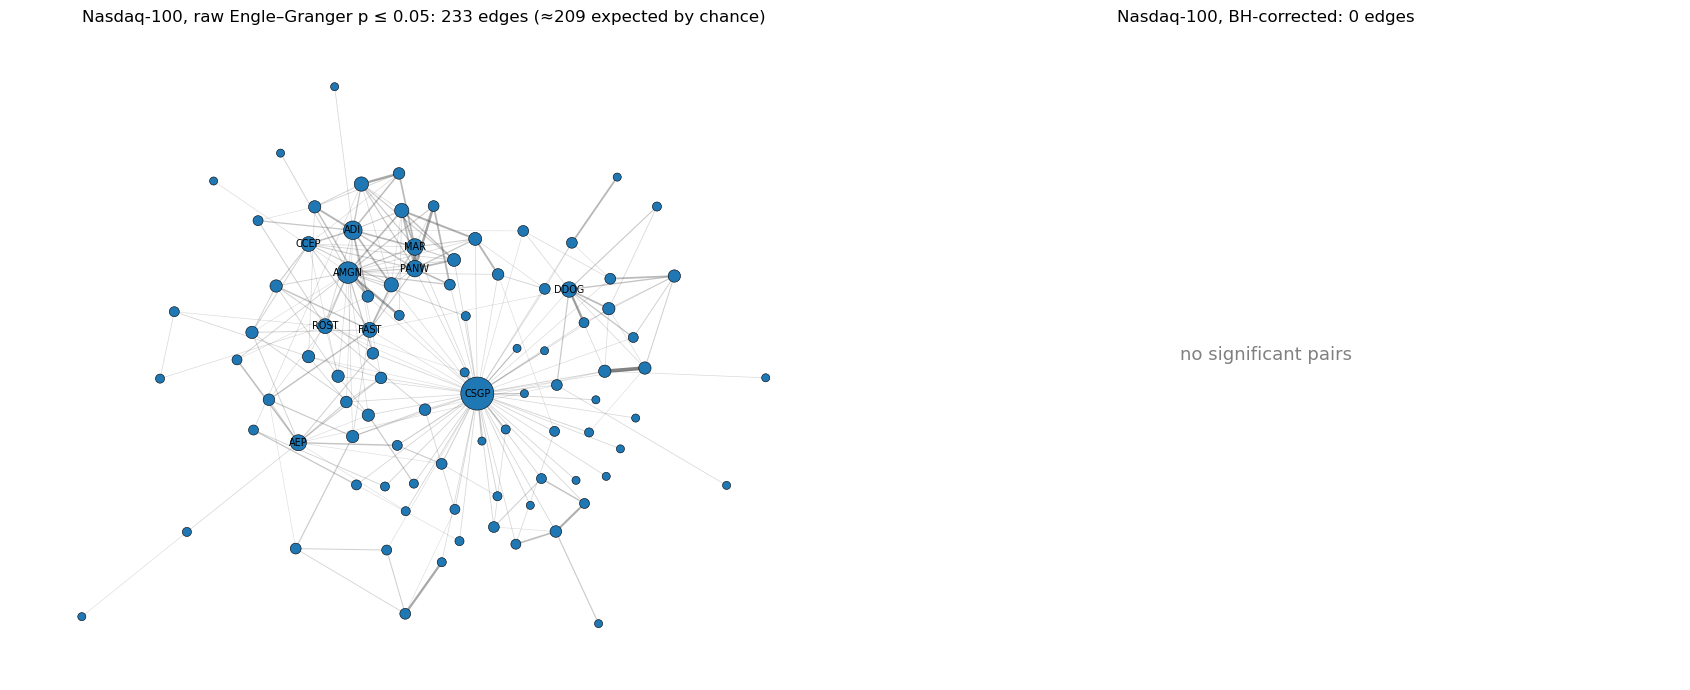

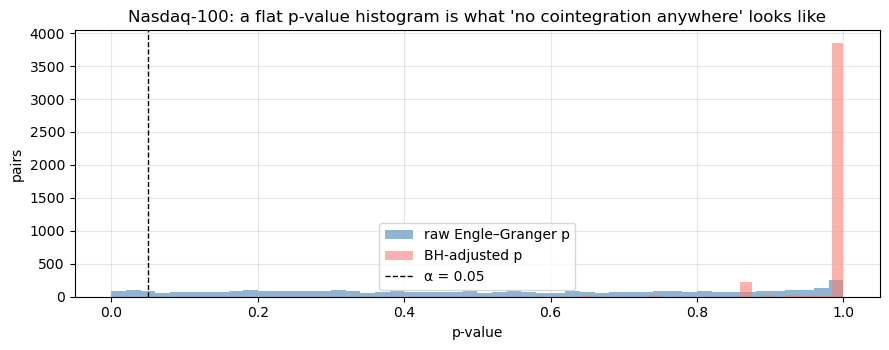

In [4]:
def build_graph(s: pd.DataFrame, mask, strength_col: str = "eg_p_fdr") -> nx.Graph:
    # Undirected graph; edge weight = -log10(p), and a distance = 1/weight for the layout.
    G = nx.Graph()
    for (a, b), p in s.loc[mask, strength_col].items():
        w = float(-np.log10(max(float(p), 1e-300)))
        G.add_edge(a, b, weight=w, dist=1.0 / max(w, 1e-6))
    return G

def draw_network(G: nx.Graph, ax, title: str, *, label: str = "all", hub_q: float = 0.9, seed: int = 42,
                 communities: bool = True, font_size: int = 7, label_min_degree: int = 2):
    # label: "all" | "hubs" (nodes with degree >= label_min_degree) | "none"
    if G.number_of_edges() == 0:
        ax.text(0.5, 0.5, "no significant pairs", ha="center", va="center", fontsize=13, color="grey")
        ax.set_title(title); ax.set_axis_off(); return [], []
    pos = nx.kamada_kawai_layout(G, weight="dist")
    deg = dict(G.degree()); dv = np.array([deg[n] for n in G.nodes()])
    hub_thr = max(2, np.quantile(dv, hub_q))
    hubs = sorted([n for n in G.nodes() if deg[n] >= hub_thr], key=lambda n: -deg[n])
    comms = list(nx.community.greedy_modularity_communities(G, weight="weight")) if communities else [set(G.nodes())]
    cid = {n: i for i, c in enumerate(comms) for n in c}
    colors = [cid[n] % 20 for n in G.nodes()]
    w = np.array([d["weight"] for *_, d in G.edges(data=True)]); wn = (w - w.min()) / (np.ptp(w) + 1e-9)
    nx.draw_networkx_edges(G, pos, width=0.4 + 2.2 * wn, alpha=0.2 + 0.5 * wn, ax=ax, edge_color="0.3")
    nx.draw_networkx_nodes(G, pos, node_size=25 + 9 * np.minimum(dv, 60), node_color=colors, cmap=plt.cm.tab20,
                           vmin=0, vmax=19, ax=ax, linewidths=0.4, edgecolors="black")
    if label != "none":
        lab = {n: n for n in G.nodes() if label == "all" or deg[n] >= max(label_min_degree, hub_thr)}
        nx.draw_networkx_labels(G, pos, labels=lab, font_size=font_size, ax=ax)
    ax.set_title(title); ax.set_axis_off()
    return hubs, comms

s_ndx = screens["ndx"]
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
G_raw = build_graph(s_ndx, s_ndx["eg_p"] <= ALPHA, strength_col="eg_p")
G_bh  = build_graph(s_ndx, s_ndx["eg_pass"])
draw_network(G_raw, axes[0], f"Nasdaq-100, raw Engle–Granger p ≤ {ALPHA}: {G_raw.number_of_edges()} edges "
                             f"(≈{int(round(ALPHA * len(s_ndx)))} expected by chance)", label="hubs", communities=False)
draw_network(G_bh,  axes[1], f"Nasdaq-100, BH-corrected: {G_bh.number_of_edges()} edges", label="none")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(s_ndx["eg_p"], bins=50, alpha=0.6, label="raw Engle–Granger p", color="steelblue")
ax.hist(s_ndx["eg_p_fdr"], bins=50, alpha=0.6, label="BH-adjusted p", color="salmon")
ax.axvline(ALPHA, color="black", ls="--", lw=1, label=f"α = {ALPHA}")
ax.set_title("Nasdaq-100: a flat p-value histogram is what 'no cointegration anywhere' looks like")
ax.set_xlabel("p-value"); ax.set_ylabel("pairs"); ax.legend(); plt.tight_layout(); plt.show()

## 3. The cointegration network (combined universe)

From here on, "significant" means **dual-gate pass**: BH-adjusted Engle–Granger *and* Johansen at 5%.
Edge strength is $-\log_{10}$ of the BH-adjusted Engle–Granger p-value.

### 3.1 Heatmap

Only tickers that take part in at least one significant pair are shown, alphabetically, upper triangle.

279 significant pairs among 239 tickers (of 488 screened)


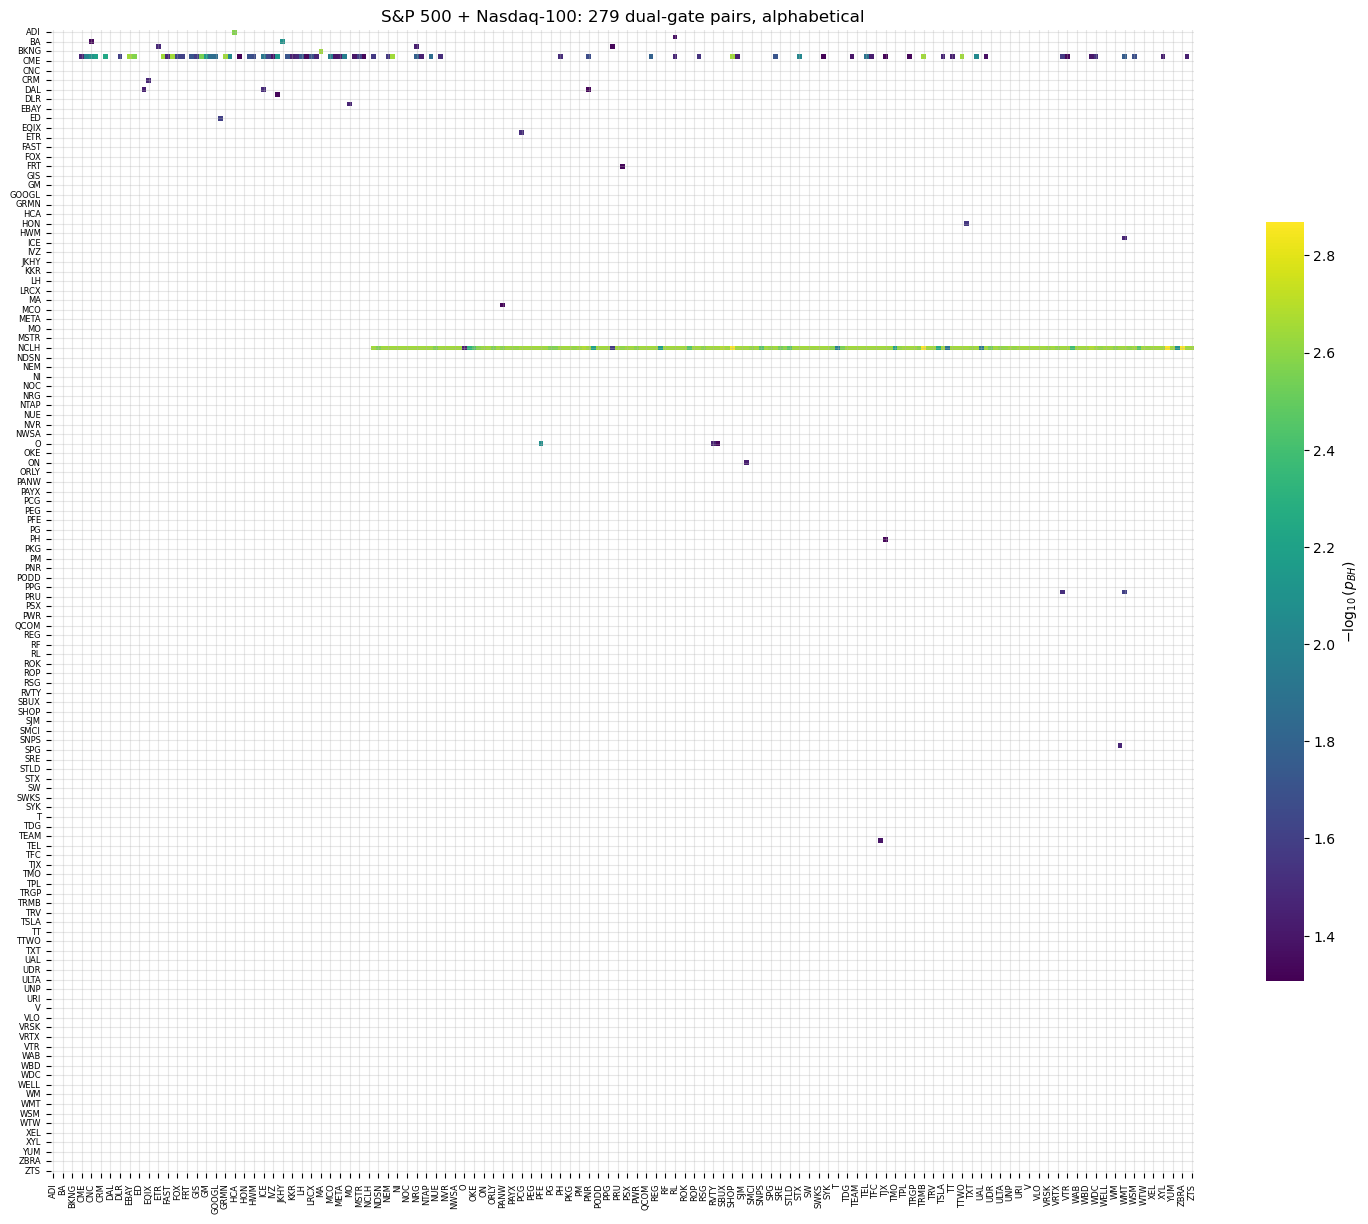

In [5]:
s_main = screens[MAIN]
SIG = s_main["verdict"] == "pass"
sig_pairs = list(s_main.index[SIG])
active = sorted({t for p in sig_pairs for t in p})
print(f"{len(sig_pairs)} significant pairs among {len(active)} tickers "
      f"(of {prices[MAIN].index.get_level_values('ticker').nunique()} screened)")

def strength_matrix(s: pd.DataFrame, mask, tickers) -> pd.DataFrame:
    M = pd.DataFrame(np.nan, index=tickers, columns=tickers)
    for (a, b), p in s.loc[mask, "eg_p_fdr"].items():
        v = -np.log10(max(float(p), 1e-300)); M.loc[a, b] = v; M.loc[b, a] = v
    return M

def plot_matrix(M: pd.DataFrame, title: str, *, cluster: bool = False, label_step: int = 1, figsize=(15, 13)):
    if cluster:                                   # hierarchical clustering on the strength profiles
        order = leaves_list(linkage(M.fillna(0.0).to_numpy(), method="average", metric="euclidean"))
        M = M.iloc[order, order]
    n = len(M)
    hide = np.tril(np.ones((n, n), dtype=bool)) | M.isna().to_numpy()      # upper triangle, blanks for non-significant
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(M, mask=hide, cmap="viridis", square=True, ax=ax,
                cbar_kws={"label": r"$-\log_{10}(p_{BH})$", "shrink": 0.6},
                xticklabels=label_step, yticklabels=label_step)
    ax.tick_params(labelsize=6); plt.setp(ax.get_xticklabels(), rotation=90)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_title(title); plt.tight_layout(); plt.show()
    return M

M_active = strength_matrix(s_main, SIG, active)
_ = plot_matrix(M_active, f"{UNIVERSES[MAIN]}: {len(sig_pairs)} dual-gate pairs, alphabetical", label_step=2)

Two rows light up and almost nothing else: the matrix is telling you that the network is a **star**, not a
web. The graph view makes that explicit.

### 3.2 Network: Kamada-Kawai layout, communities and hubs

Node size is degree, colour is the greedy-modularity community, edge width and opacity are strength.
Hubs are nodes at or above the 90th percentile of degree.

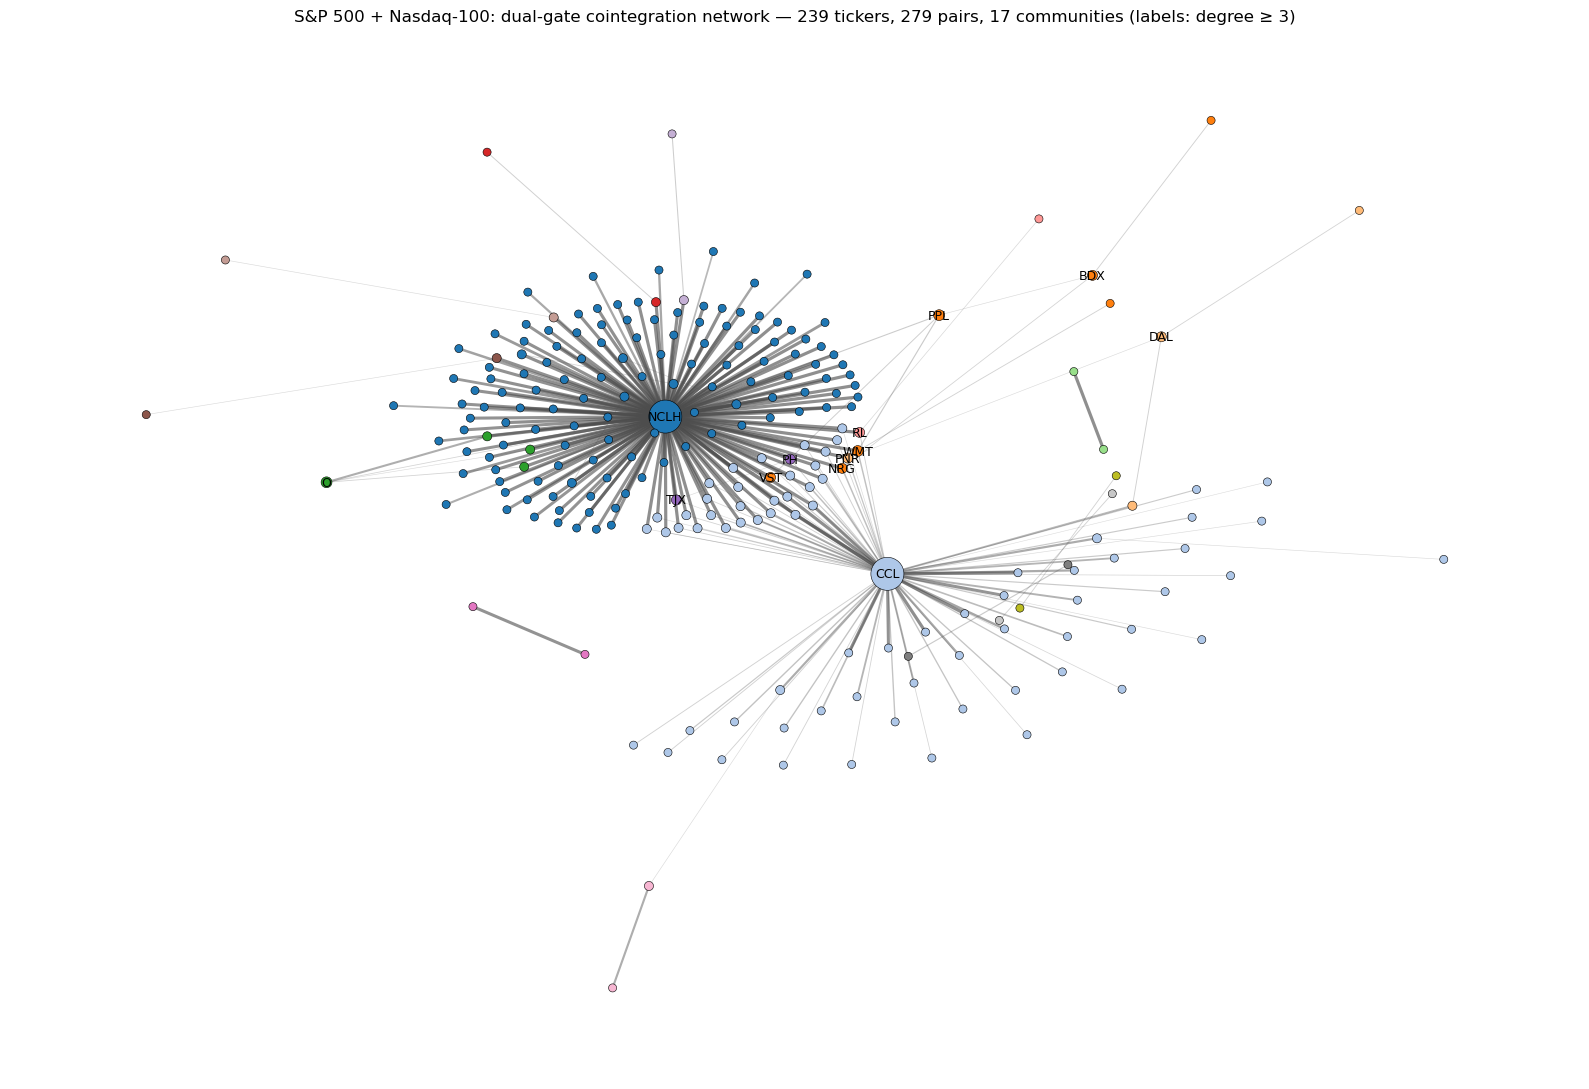

59 hubs at or above the 90th percentile of degree (≥ 2); top 15:
      degree  share of all edges  mean strength  community
NCLH     172                0.62           2.59          0
CCL       78                0.28           1.76          1
WMT        4                0.01           1.87          2
O          4                0.01           1.57          4
PPL        4                0.01           1.51          2
NRG        3                0.01           1.96          2
PH         3                0.01           1.82          8
PNR        3                0.01           1.88          3
RL         3                0.01           1.83          7
TJX        3                0.01           1.76          8
VST        3                0.01           1.91          2
DAL        3                0.01           1.42          3
BDX        3                0.01           1.42          2
SHOP       2                0.01           2.76          1
TRMB       2                0.01           2.76   

In [6]:
G = build_graph(s_main, SIG)
fig, ax = plt.subplots(figsize=(16, 11))
hubs, comms = draw_network(G, ax, "", label="hubs", font_size=9, label_min_degree=3)
ax.set_title(f"{UNIVERSES[MAIN]}: dual-gate cointegration network — {G.number_of_nodes()} tickers, "
             f"{G.number_of_edges()} pairs, {len(comms)} communities (labels: degree ≥ 3)")
plt.tight_layout(); plt.show()

deg = pd.Series(dict(G.degree())).sort_values(ascending=False)
strength = {n: np.mean([d["weight"] for _, _, d in G.edges(n, data=True)]) for n in G.nodes()}
hub_table = pd.DataFrame({"degree": deg, "share of all edges": deg / G.number_of_edges(),
                          "mean strength": pd.Series(strength),
                          "community": pd.Series({n: i for i, c in enumerate(comms) for n in c})}).loc[hubs]
print(f"{len(hubs)} hubs at or above the 90th percentile of degree (≥ {max(2, np.quantile(deg, 0.9)):.0f}); top 15:")
print(hub_table.head(15).to_string(float_format="{:.2f}".format))
print(f"\nAre the two mega-hubs cointegrated with each other? "
      f"{'yes' if G.has_edge(*deg.index[:2]) else 'no'} ({deg.index[0]}/{deg.index[1]} is not a dual-gate pair)"
      if not G.has_edge(*deg.index[:2]) else "")

### 3.3 Degree distribution, and the network without its hubs

A handful of tickers carry most of the edges. Removing the biggest hubs shows what structure is left.

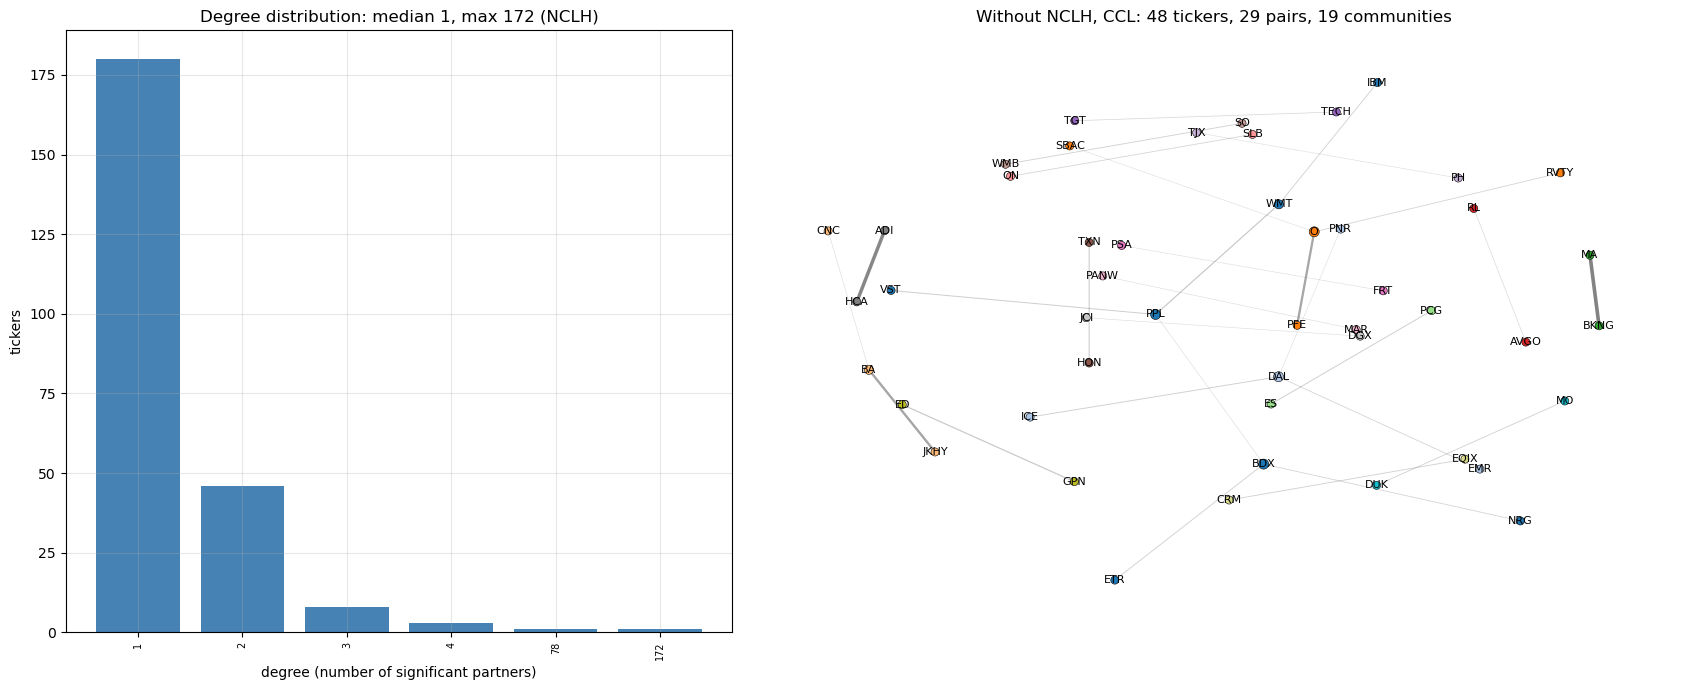

The 2 mega-hub(s) account for 250 of 279 edges.


In [7]:
MEGA = list(deg[deg > 20].index)                    # hubs that dominate the picture
G_rest = G.copy(); G_rest.remove_nodes_from(MEGA); G_rest.remove_nodes_from(list(nx.isolates(G_rest)))

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [1, 1.4]})
ax = axes[0]
counts = deg.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color="steelblue")
ax.set_xlabel("degree (number of significant partners)"); ax.set_ylabel("tickers")
ax.set_title(f"Degree distribution: median {int(deg.median())}, max {int(deg.max())} ({deg.idxmax()})")
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
hubs_rest, comms_rest = draw_network(G_rest, axes[1], "", label="all", font_size=8)
axes[1].set_title(f"Without {', '.join(MEGA)}: {G_rest.number_of_nodes()} tickers, {G_rest.number_of_edges()} pairs, "
                  f"{len(comms_rest)} communities")
plt.tight_layout(); plt.show()
print(f"The {len(MEGA)} mega-hub(s) account for {sum(deg[m] for m in MEGA) - (1 if len(MEGA) > 1 and G.has_edge(*MEGA[:2]) else 0)} "
      f"of {G.number_of_edges()} edges.")

**What the star means.** The cruise lines lost most of their value in early 2020 and recovered slowly and
partially; that single low-frequency path is close enough to the trend of many unrelated stocks, over
this window, for both cointegration tests to pass. A hub with more than a hundred "cointegrated" partners
is not a hundred trading opportunities — it is one shared trend, and a warning that the
2020–2025 window is dominated by a regime rather than by pair-specific mean reversion. The two hubs are
not cointegrated with *each other*: they are two separate stars.

The pipeline notebooks' walk-forward selection lands on pairs from exactly this family, and with a twist
worth knowing: the pair they end up trading, **CCL/STT, is not itself a dual-gate pass** at 5% (its
BH-adjusted Engle–Granger p-value is about 0.10; the Johansen gate passes), whereas NCLH/STT is. nb02's
shortlist is the top of a composite pre-score computed over *all* screened pairs, not over the dual-gate
survivors, so the screen's verdict is informative there but not binding — see `partners("STT")` in §5.

### 3.4 Clustered heatmap

The same matrix with tickers reordered by hierarchical clustering of their strength profiles, so that
whatever block structure exists becomes visible.

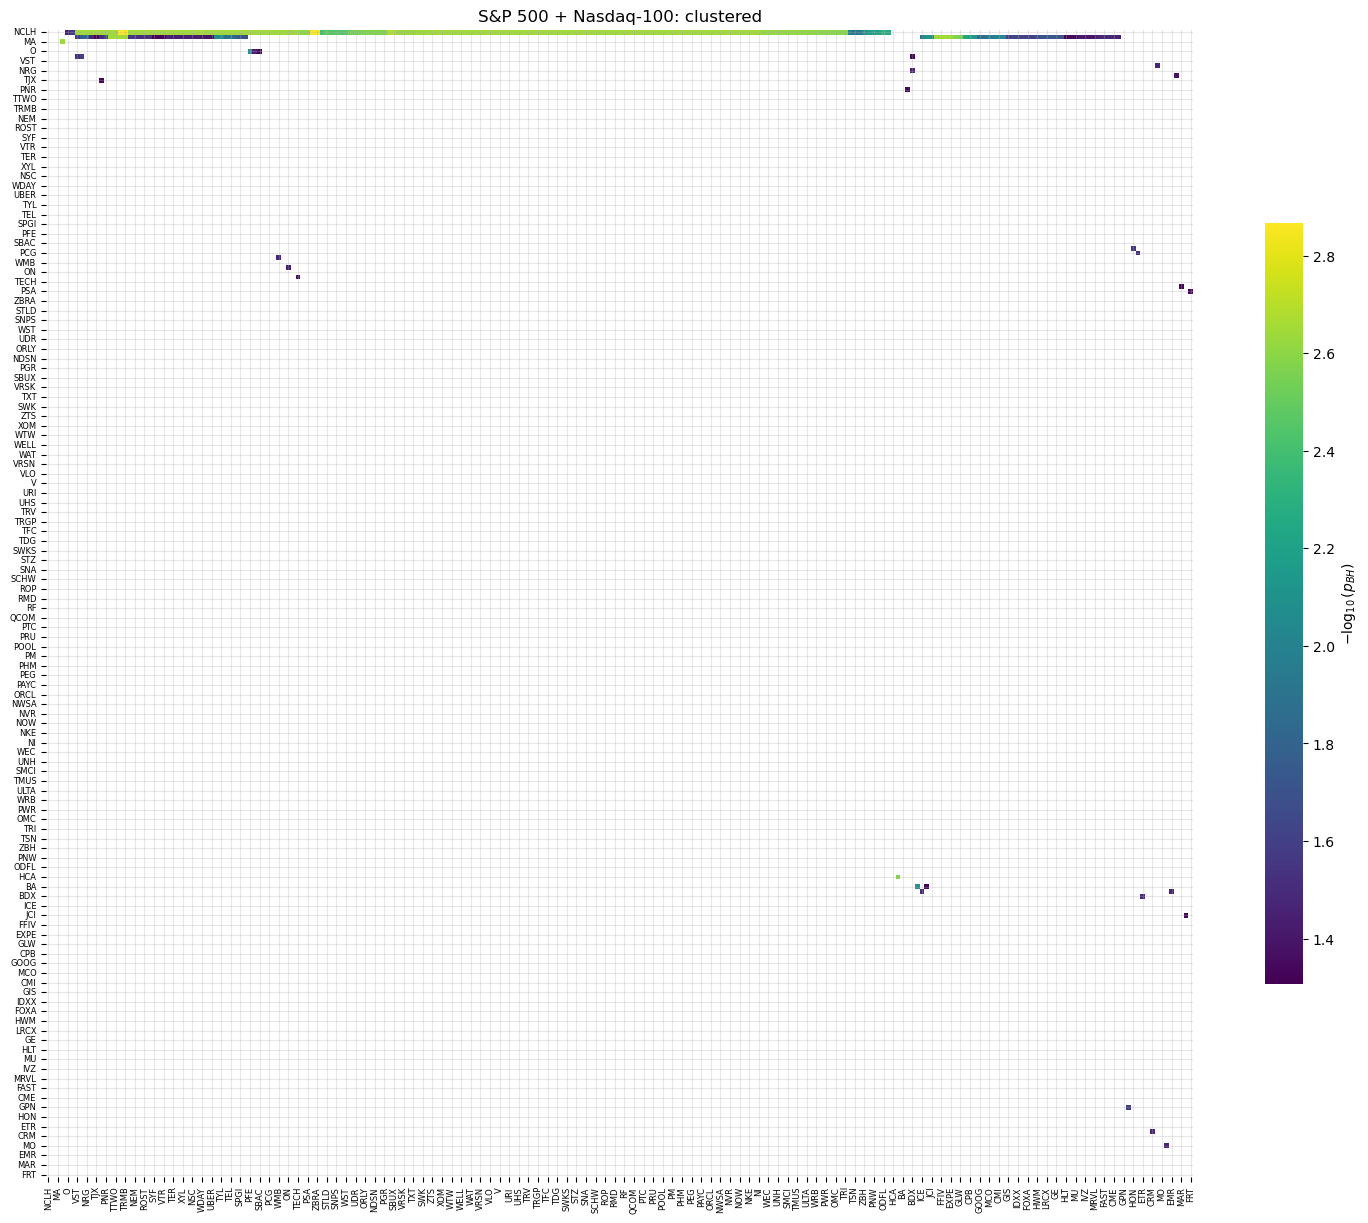

In [8]:
_ = plot_matrix(M_active, f"{UNIVERSES[MAIN]}: clustered", cluster=True, label_step=2)

## 4. Trading diagnostics for the surviving pairs

Two spreads are computed for every dual-gate pair, and it matters which one you look at:

* The **static spread** — the Engle–Granger residual, price minus a fixed OLS hedge — is the object the
  cointegration test was run on. Its **half-life** is the honest measure of tradeability at daily
  frequency: a few days to a few weeks is tradeable, hundreds of days is cointegration you cannot
  monetise, `NaN` means no mean reversion was found.
* The **Kalman spread** (the pipeline's `fit_kalman_hedge`, smoothed, EM-fitted, cached) is what the
  strategy notebooks trade. A time-varying hedge ratio makes *any* residual look stationary
  (`tv_cointegration_kalman.ipynb`), so its ADF verdict and half-life describe the filter, not the pair.
  It is kept here for comparison — the third panel below shows by how much the filter compresses
  half-lives.

Testing stationarity:   0%|          | 0/279 [00:00<?, ?it/s]

Testing stationarity:   1%|          | 2/279 [00:01<04:09,  1.11it/s]

Testing stationarity:   7%|▋         | 19/279 [00:01<00:19, 13.50it/s]

Testing stationarity:  23%|██▎       | 64/279 [00:02<00:03, 54.87it/s]

Testing stationarity:  49%|████▊     | 136/279 [00:02<00:01, 134.17it/s]

...

Testing stationarity:   0%|          | 0/279 [00:00<?, ?it/s]

Testing stationarity:  22%|██▏       | 62/279 [00:00<00:00, 612.48it/s]

Testing stationarity:  49%|████▉     | 137/279 [00:00<00:00, 691.59it/s]

Testing stationarity:  76%|███████▌  | 211/279 [00:00<00:00, 711.35it/s]

279 pairs | static half-life: estimable 279, median 43 bars, in the tradeable band 5–30: 23 | Kalman half-life: median 0.39 bars, 'stationary' verdicts 278 of 279


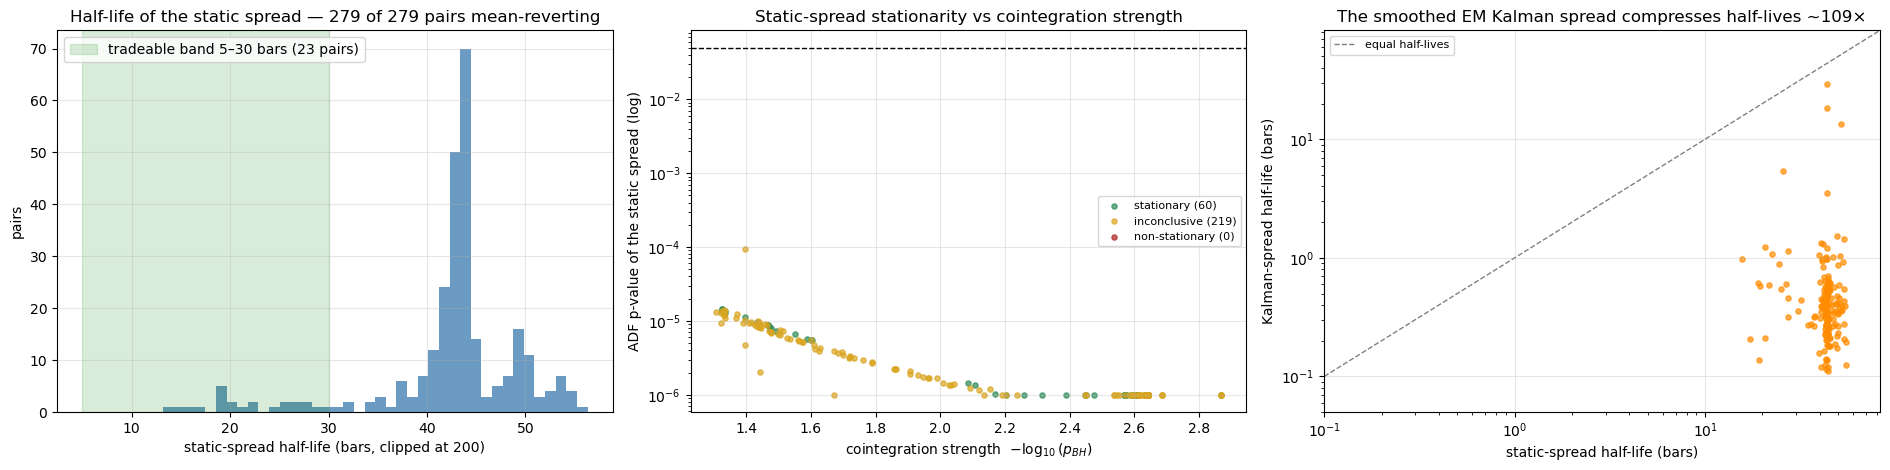

In [9]:
px = prices[MAIN]["close"].unstack("ticker")

def ols_spread(a: str, b: str):
    y, x = px[a].to_numpy(float), px[b].to_numpy(float)
    X = np.column_stack([np.ones_like(x), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return pd.Series(y - X @ beta, index=px.index, name="resid"), float(beta[1])

ols = {p: ols_spread(*p) for p in sig_pairs}
stat_ols = summarize_spread_stationarity_joblib({p: r.to_frame() for p, (r, _) in ols.items()},
                                                alpha=ALPHA, regression="c", show_progress=True)

kf_cache = CACHE / f"viz_kalman_{MAIN}.pkl"
if kf_cache.exists():
    states = pd.read_pickle(kf_cache)
else:
    t0 = time.time()
    states, _ = fit_kalman_hedge(prices[MAIN], pairs=sig_pairs, mode="smooth", em_iters=5, q=1e-5,
                                 return_params=True, show_progress=True)
    pd.to_pickle(states, kf_cache)
    print(f"Kalman states for {len(states)} pairs in {time.time() - t0:.0f}s")
stat_kf = summarize_spread_stationarity_joblib(states, alpha=ALPHA, regression="c", show_progress=True)

diag = (s_main.loc[sig_pairs, ["eg_p", "eg_p_fdr", "joh_stat"]]
        .join(stat_ols[["adf_p", "halflife", "verdict"]]
              .rename(columns={"adf_p": "adf_p_static", "halflife": "halflife_static", "verdict": "spread_verdict_static"}))
        .join(stat_kf[["halflife", "verdict"]]
              .rename(columns={"halflife": "halflife_kalman", "verdict": "spread_verdict_kalman"})))
diag["hedge_ratio_static"] = [ols[p][1] for p in diag.index]
diag["strength"] = -np.log10(diag["eg_p_fdr"].clip(lower=1e-300))

HL_LO, HL_HI = 5, 30
in_band = diag["halflife_static"].between(HL_LO, HL_HI)
print(f"{len(diag)} pairs | static half-life: estimable {diag['halflife_static'].notna().sum()}, "
      f"median {diag['halflife_static'].median():.0f} bars, in the tradeable band {HL_LO}–{HL_HI}: {int(in_band.sum())} | "
      f"Kalman half-life: median {diag['halflife_kalman'].median():.2f} bars, "
      f"'stationary' verdicts {(diag['spread_verdict_kalman'] == 'stationary').sum()} of {len(diag)}")

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
ax = axes[0]
hl = diag["halflife_static"].dropna().clip(upper=200)
ax.hist(hl, bins=40, color="steelblue", alpha=0.8)
ax.axvspan(HL_LO, HL_HI, color="green", alpha=0.15, label=f"tradeable band {HL_LO}–{HL_HI} bars ({int(in_band.sum())} pairs)")
ax.set_xlabel("static-spread half-life (bars, clipped at 200)"); ax.set_ylabel("pairs"); ax.legend()
ax.set_title(f"Half-life of the static spread — {len(hl)} of {len(diag)} pairs mean-reverting")
ax = axes[1]
for verdict, color in (("stationary", "seagreen"), ("inconclusive", "goldenrod"), ("non-stationary", "firebrick")):
    d = diag[diag["spread_verdict_static"] == verdict]
    ax.scatter(d["strength"], d["adf_p_static"].clip(lower=1e-6), s=14, alpha=0.7, color=color, label=f"{verdict} ({len(d)})")
ax.set_yscale("log"); ax.axhline(ALPHA, color="black", ls="--", lw=1)
ax.set_xlabel(r"cointegration strength  $-\log_{10}(p_{BH})$"); ax.set_ylabel("ADF p-value of the static spread (log)")
ax.set_title("Static-spread stationarity vs cointegration strength"); ax.legend(fontsize=8)
ax = axes[2]
both = diag.dropna(subset=["halflife_static", "halflife_kalman"])
ax.scatter(both["halflife_static"], both["halflife_kalman"], s=14, alpha=0.7, color="darkorange")
lim = (0.1, max(both["halflife_static"].max(), 1) * 1.5)
ax.plot(lim, lim, color="grey", ls="--", lw=1, label="equal half-lives")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(0.05, lim[1])
ax.set_xlabel("static-spread half-life (bars)"); ax.set_ylabel("Kalman-spread half-life (bars)")
ax.set_title(f"The smoothed EM Kalman spread compresses half-lives ~{(both['halflife_static'] / both['halflife_kalman']).median():.0f}×")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the diagnostics.** Every dual-gate pair has a mean-reverting static spread — the screen
guaranteed that — but the half-lives cluster around forty bars, and the hub pairs all sit there: a
two-month half-life is a slow, regime-driven reversion, not a daily trading signal. Only a couple of dozen
pairs fall in the tradeable band, and none of them involve the cruise-line hubs. Most static spreads are
labelled *inconclusive* rather than *stationary*: ADF rejects the unit root (as the screen implies) but
KPSS rejects level-stationarity too, which is what a spread that reverts slowly around a drifting level
looks like. The third panel is the `tv_cointegration_kalman.ipynb` result in one picture: the smoothed,
EM-fitted Kalman spread reports half-lives of a fraction of a bar for the very same pairs.

### 4.1 Gallery: the most tradeable spreads

Dual-gate pairs whose static-spread half-life falls in the tradeable band, ranked by BH p-value. Each
panel is the standardised static spread over the whole window with ±2σ lines; the eye is a good judge of
whether "mean-reverting" means regular oscillation or one big excursion that the test mistook for a
relationship.

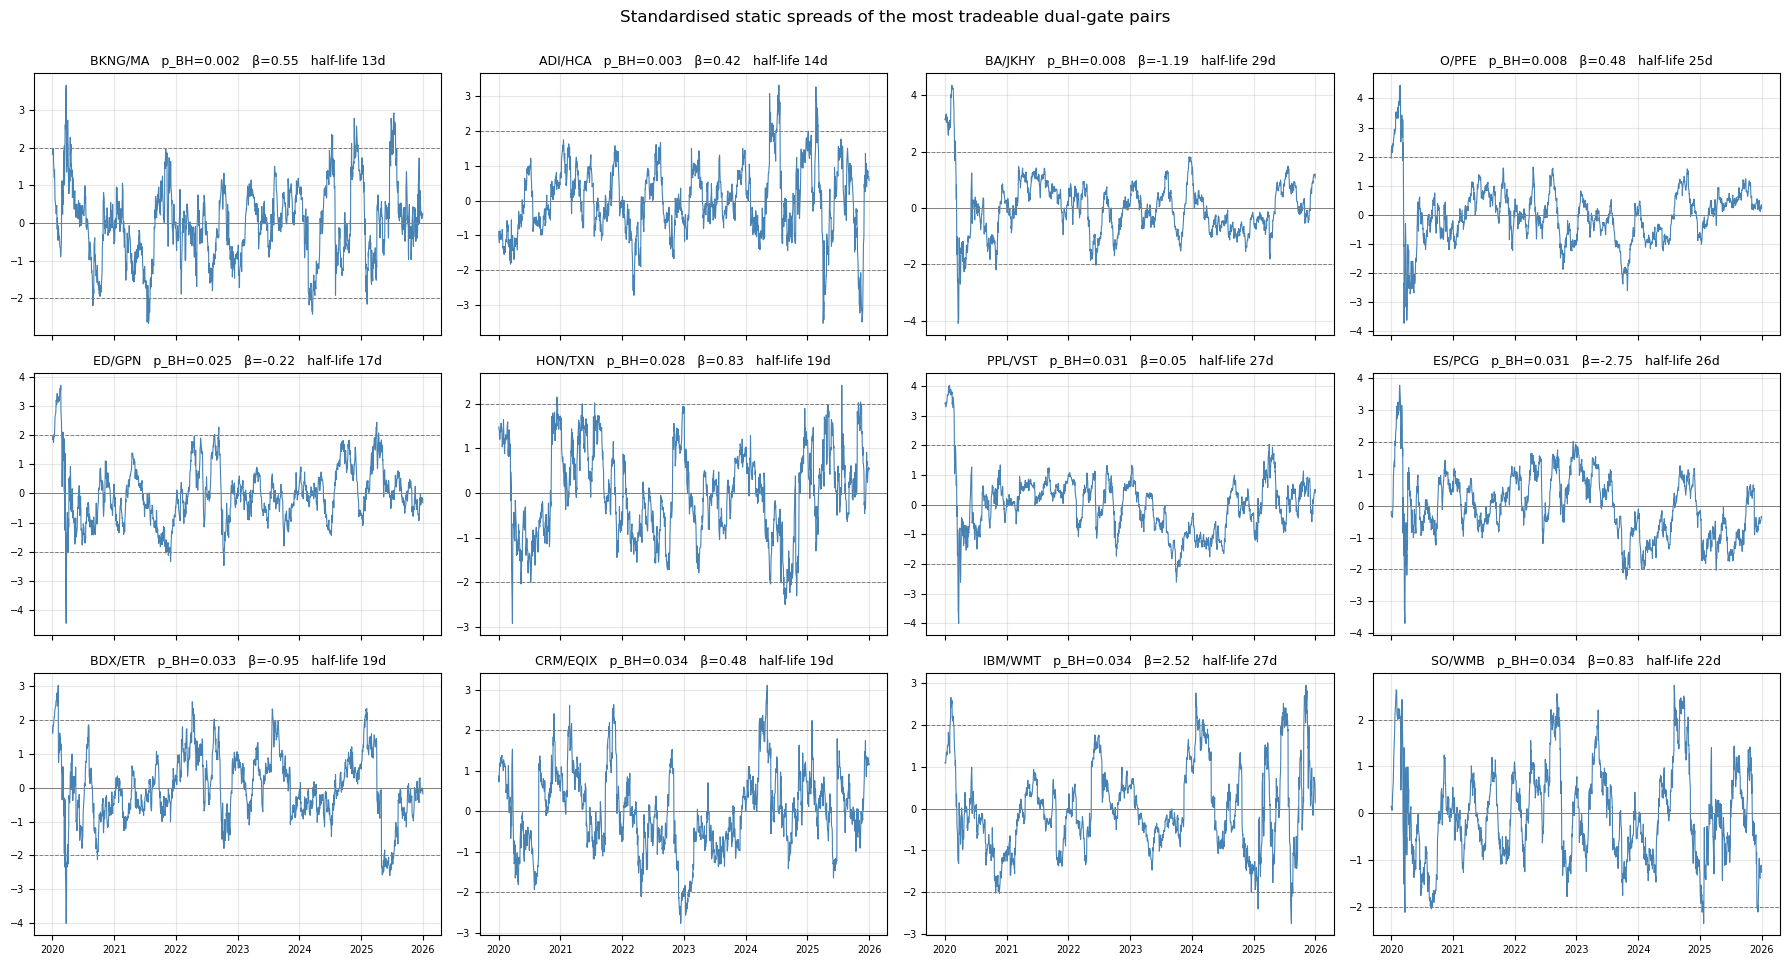

In [10]:
top = diag[in_band].sort_values("eg_p_fdr").head(12)
if top.empty:
    raise SystemExit(f"no pair has a half-life in the {HL_LO}–{HL_HI} band")
ncol = 4; nrow = int(np.ceil(len(top) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 3.2 * nrow), sharex=True, squeeze=False)
for ax, ((a, b), row) in zip(axes.ravel(), top.iterrows()):
    r = ols[(a, b)][0]; z = (r - r.mean()) / r.std()
    ax.plot(z.index, z, lw=0.8, color="steelblue")
    for lvl in (-2, 0, 2): ax.axhline(lvl, color="grey", ls="--" if lvl else "-", lw=0.7)
    ax.set_title(f"{a}/{b}   p_BH={row['eg_p_fdr']:.3f}   β={row['hedge_ratio_static']:.2f}   half-life {row['halflife_static']:.0f}d", fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(top):]: ax.set_axis_off()
fig.suptitle("Standardised static spreads of the most tradeable dual-gate pairs", y=1.0)
plt.tight_layout(); plt.show()

## 5. Partner query

Everything above, for one ticker: its cointegrated partners with the screen statistics and the spread
diagnostics. `only_pass=False` shows the raw candidates too — useful to see what the BH correction removed.

In [11]:
def partners(ticker: str, universe: str = MAIN, *, only_pass: bool = True) -> pd.DataFrame:
    s = screens[universe]; t = ticker.upper()
    a = s.index.get_level_values(0); b = s.index.get_level_values(1)
    rows = s[(a == t) | (b == t)]
    if only_pass:
        rows = rows[rows["verdict"] == "pass"]
    if rows.empty:
        return pd.DataFrame(columns=["eg_p", "eg_p_fdr", "joh_stat", "verdict"])
    out = pd.DataFrame({
        "partner": np.where(rows.index.get_level_values(0) == t, rows.index.get_level_values(1), rows.index.get_level_values(0)),
        "eg_p": rows["eg_p"].values, "eg_p_fdr": rows["eg_p_fdr"].values,
        "joh_stat": rows["joh_stat"].values, "verdict": rows["verdict"].values}, index=rows.index)
    if universe == MAIN:
        extra = diag.reindex(rows.index)[["hedge_ratio_static", "halflife_static", "spread_verdict_static", "halflife_kalman"]]
        out = out.join(extra)
    return out.set_index("partner").sort_values("eg_p_fdr")

print("STT — dual-gate partners (note that CCL, the pipeline notebooks' choice, is not among them):")
display(partners("STT"))
print("\nSTT — all screened partners with raw p ≤ 0.05, including the failures:")
display(partners("STT", only_pass=False).query("eg_p <= @ALPHA").sort_values("eg_p").head(8))
print("\nNCLH — the mega-hub, top 10 of its partners:")
display(partners("NCLH").head(10))
print("\nASML on the Nasdaq-100 — the old notebook's example, after BH:", len(partners("ASML", "ndx")), "partners")
print("…and its three best raw candidates, with what BH did to them:")
display(partners("ASML", "ndx", only_pass=False).sort_values("eg_p").head(3))

STT — dual-gate partners (note that CCL, the pipeline notebooks' choice, is not among them):


,eg_p,eg_p_fdr,joh_stat,verdict,hedge_ratio_static,halflife_static,spread_verdict_static,halflife_kalman
partner,,,,,,,,
NCLH,8.806304e-07,0.002274,29.732358,pass,0.16749,42.830314,inconclusive,0.227787



STT — all screened partners with raw p ≤ 0.05, including the failures:


,eg_p,eg_p_fdr,joh_stat,verdict,hedge_ratio_static,halflife_static,spread_verdict_static,halflife_kalman
partner,,,,,,,,
NCLH,8.806304e-07,0.002274,29.732358,pass,0.16749,42.830314,inconclusive,0.227787
CCL,3.064757e-04,0.096307,30.949503,fail,NaN,NaN,NaN,NaN
SYF,7.242893e-04,0.133273,15.586732,fail,NaN,NaN,NaN,NaN
BA,7.783326e-04,0.133273,18.832514,fail,NaN,NaN,NaN,NaN
JCI,9.800227e-04,0.133273,22.239973,fail,NaN,NaN,NaN,NaN
CSCO,1.203714e-03,0.141339,21.260363,fail,NaN,NaN,NaN,NaN
DGX,1.661878e-03,0.169218,22.780877,fail,NaN,NaN,NaN,NaN
EBAY,2.888647e-03,0.233188,18.224890,fail,NaN,NaN,NaN,NaN



NCLH — the mega-hub, top 10 of its partners:


,eg_p,eg_p_fdr,joh_stat,verdict,hedge_ratio_static,halflife_static,spread_verdict_static,halflife_kalman
partner,,,,,,,,
SHOP,1.544746e-08,0.001355,37.268515,pass,0.068046,35.762856,inconclusive,0.275263
TRMB,2.923744e-08,0.001355,42.340817,pass,0.164193,37.884567,inconclusive,0.322331
XYZ,4.559848e-08,0.001355,34.453662,pass,0.041330,37.210426,stationary,0.315307
ZBRA,3.793752e-08,0.001355,36.397732,pass,0.026021,38.422208,inconclusive,NaN
PNC,1.169097e-07,0.002069,33.278533,pass,0.094493,40.590889,inconclusive,NaN
SBUX,1.055287e-07,0.002069,38.528619,pass,0.189170,41.517239,inconclusive,NaN
WDAY,1.218741e-07,0.002069,42.543171,pass,0.055298,37.724386,inconclusive,NaN
TGT,8.666114e-07,0.002274,28.976599,pass,0.025664,42.609326,inconclusive,NaN
TJX,1.960493e-06,0.002274,26.639595,pass,0.011775,43.634506,inconclusive,0.248451



ASML on the Nasdaq-100 — the old notebook's example, after BH: 0 partners
…and its three best raw candidates, with what BH did to them:


,eg_p,eg_p_fdr,joh_stat,verdict
partner,,,,
AMD,0.036684,0.864581,13.382660,fail
ROST,0.039854,0.864581,13.031503,fail
INTU,0.055091,0.900033,10.919072,fail


## 6. Notes and limitations

* **One window, one regime.** Everything here is 2020–2025 daily data. The cruise-line star is a property of
  that window; the audit should be re-run on other windows before trusting any edge.
* **BH controls the false-discovery *rate*, not each edge.** At 5% FDR, about one in twenty surviving pairs
  is still expected to be spurious, and the Johansen gate at 5% is not corrected at all.
* **Community structure is descriptive.** Greedy modularity on a star-shaped graph mostly partitions the
  hub's neighbours; it is shown for orientation, not as a claim about sectors.
* **Tradeability is judged on the static spread.** The Kalman spread's half-lives and verdicts describe
  the filter, which has already made the residual as stationary as it can; see
  `tv_cointegration_kalman.ipynb` for why that is not evidence of a long-run relation.
* **Caches.** Delete `notebooks/cache/viz_*` to force fresh downloads and screens; the combined-universe
  screen takes several minutes.